# Отток клиентов «Бета-Банка»

## 1. Загрузка и подготовка данных

### 1.1 Первичный осмотр

In [1]:
import pandas as pd
data = pd.read_csv('data/Churn.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           9091 non-null   float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB


In [2]:
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1.0,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2.0,125510.82,1,1,1,79084.10,0


После первичного осмотра выяснилось, что всего 14 столбцов и 10000 строк, пропуски есть только в Tenure.

### 1.2 Отбор признаков — что выбрасываем и почему

В обучении я буду использовать все признаки, кроме RowNumber, CustomerId и Surname. RowNumber и CustomerId не несут смысловой нагрузки и уникальны по строкам. Surname — 2932 уникальных значения на 6000 обучающих объектов, признаков станет больше, чем примеров; и фамилия в банковской модели работает прокси национальности, из-за чего банк начнёт по-разному обращаться с людьми по признаку, к их поведению не относящемуся.

In [3]:
data = data.drop(['RowNumber', 'CustomerId', 'Surname' ], axis = 1)

### 1.3 Пропуски: сколько, информативны ли, как заполняем

In [4]:
data['Tenure'].isna().mean() 

np.float64(0.0909)

In [5]:
print(data.groupby(data['Tenure'].isna())['Exited'].mean())

Tenure
False    0.203938
True     0.201320
Name: Exited, dtype: float64


Пропущено всего 9 процентов. Проверили долю оттока среди клиентов с пропуском и без — числа примерно равны, поэтому затрём пропуски медианой внутри пайплайна. Медиана устойчивее к выбросам, поэтому выбор пал на неё, а не на среднее.

### 1.4 Дубликаты

In [6]:
data.duplicated().sum()

np.int64(0)

Дубликатов в строках нет — идём дальше.

### 1.5 Что видно в признаках (NumOfProducts, Balance)

In [7]:
data.groupby('NumOfProducts')['Exited'].mean()

NumOfProducts
1    0.277144
2    0.075817
3    0.827068
4    1.000000
Name: Exited, dtype: float64

In [8]:
data['NumOfProducts'].value_counts()

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

NumOfProducts немонотонен. Отток минимален при двух продуктах и взлетает при трёх и четырёх. Значит, для линейной модели этот признак числом не годится — уходит в категориальные. Группы с 3 и 4 продуктами очень малы, основная доля приходится на 1 и 2.

In [9]:
data['Balance'].value_counts()

Balance
0.00         3617
130170.82       2
105473.74       2
129845.26       1
117419.35       1
             ... 
88381.21        1
155060.41       1
57369.61        1
75075.31        1
150725.53       1
Name: count, Length: 6382, dtype: int64

<Axes: >

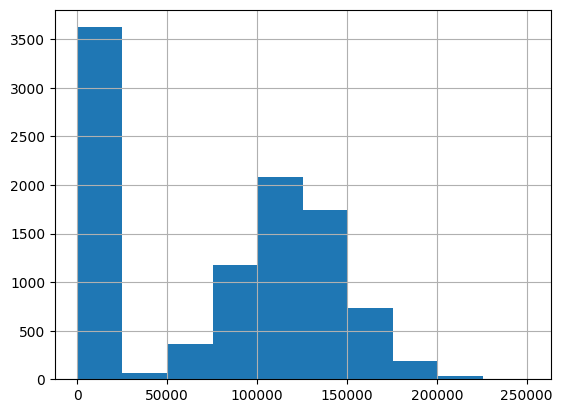

In [10]:
data['Balance'].hist()

Есть 2 пика — в нуле и в окрестности 120000, поэтому было решено разделить клиентов на тех, у кого баланс пуст, и остальных.

In [11]:
data['Is_Not_Empty'] = data['Balance'].apply(lambda x: 1 if x != 0 else 0)

### 1.6 Разбиение на три выборки + проверка

In [12]:
from sklearn.model_selection import train_test_split
data_train, data_valid = train_test_split(data, test_size=0.2,  random_state=12345,  stratify=data['Exited'])
data_train, data_test = train_test_split(data_train, test_size=0.25,  random_state=12345,  stratify=data_train['Exited'])

In [13]:
print(len(data_train), len(data_valid), len(data_test))

6000 2000 2000


In [14]:
print(data_train['Exited'].value_counts(normalize=True))
print(data_valid['Exited'].value_counts(normalize=True))
print(data_test['Exited'].value_counts(normalize=True))

Exited
0    0.796167
1    0.203833
Name: proportion, dtype: float64
Exited
0    0.7965
1    0.2035
Name: proportion, dtype: float64
Exited
0    0.7965
1    0.2035
Name: proportion, dtype: float64


In [15]:
features_valid = data_valid.drop('Exited', axis=1)
target_valid   = data_valid['Exited']
features_train = data_train.drop('Exited', axis=1)
target_train   = data_train['Exited']
features_test = data_test.drop('Exited', axis=1)
target_test   = data_test['Exited']

Данные разбиты на 3 выборки с сохранением пропорций.

### 1.7 Пайплайн предобработки + проверка размерности

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [17]:
numeric_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary', 'HasCrCard', 'IsActiveMember', 'Is_Not_Empty']
categorical_features = ['Geography', 'Gender', 'NumOfProducts']

In [18]:
assert set(numeric_features) | set(categorical_features) == set(features_train.columns)
assert 'Exited' not in features_train.columns

In [19]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder( handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


In [20]:
preprocessor.fit_transform(features_train).shape

(6000, 17)

Размерности сошлись.

### Вывод по разделу 1

Обучать модель буду с 3 категориальными признаками и 8 численными. Из 14 столбцов осталось 11. Пропуски были только в Tenure — затрём медианой. Данные разбиты 60/20/20 со стратификацией и сохранением долей. Благодаря собранному пайплайну всё готово к обучению.

NumOfProducts немонотонен, а Balance двугорбый, поэтому линейной модели будет неудобно. Стоит попробовать деревья: у них есть шанс обогнать логистическую регрессию, так как им всё равно на немонотонность — благодаря своему устройству они просто создают узлы-вопросы и преодолевают её.

## 2. Баланс классов и модель без учёта дисбаланса

### Базовый уровень. DummyClassifier

In [21]:
from sklearn.dummy import DummyClassifier
import numpy as np

In [22]:
dumm_most_frequent = DummyClassifier(strategy='most_frequent', random_state = 12345).fit(features_train, target_train)
dumm_stratified = DummyClassifier(strategy='stratified', random_state = 12345).fit(features_train, target_train)
dumm_constant = DummyClassifier(strategy= 'constant', random_state = 12345, constant=1).fit(features_train, target_train)

In [23]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score


In [24]:
dumm_most_frequent_pred = dumm_most_frequent.predict(features_valid)
dumm_stratified_pred = dumm_stratified.predict(features_valid)
dumm_constant_pred = dumm_constant.predict(features_valid)

In [25]:
dumm_most_frequent_ac = accuracy_score(target_valid, dumm_most_frequent_pred)
dumm_most_frequent_f1= f1_score(target_valid, dumm_most_frequent_pred)
dumm_most_frequent_p= precision_score(target_valid, dumm_most_frequent_pred, zero_division=np.nan)
dumm_most_frequent_r= recall_score(target_valid, dumm_most_frequent_pred, zero_division=np.nan)

dumm_stratified_ac = accuracy_score(target_valid, dumm_stratified_pred)
dumm_stratified_f1= f1_score(target_valid, dumm_stratified_pred)
dumm_stratified_p= precision_score(target_valid, dumm_stratified_pred, zero_division=np.nan)
dumm_stratified_r= recall_score(target_valid, dumm_stratified_pred, zero_division=np.nan)

dumm_constant_ac = accuracy_score(target_valid, dumm_constant_pred)
dumm_constant_f1= f1_score(target_valid, dumm_constant_pred)
dumm_constant_p= precision_score(target_valid, dumm_constant_pred, zero_division=np.nan)
dumm_constant_r= recall_score(target_valid, dumm_constant_pred, zero_division=np.nan)

In [26]:
temp = [[dumm_most_frequent_ac, dumm_most_frequent_f1, dumm_most_frequent_p, dumm_most_frequent_r],
      [dumm_stratified_ac, dumm_stratified_f1, dumm_stratified_p, dumm_stratified_r],
      [dumm_constant_ac, dumm_constant_f1, dumm_constant_p, dumm_constant_r]
     ]
sverka = pd.DataFrame(temp, columns=['accuracy_score', 'f1_score', 'precision_score', 'recall_score'], index = ['most_frequent', 'stratified', 'constant'])
sverka

,accuracy_score,f1_score,precision_score,recall_score
most_frequent,0.7965,0.000000,NaN,0.000000
stratified,0.6825,0.228433,0.225962,0.230958
constant,0.2035,0.338180,0.203500,1.000000


Константа «все уйдут» даёт F1 = 0.338. Не ноль, не ерунда — треть. Модель, которая вообще не смотрит на данные и всем ставит «уйдёт», получает precision 0.2035 (доля класса) и recall 1.0, а F1 усредняет их по гармонике.

Отсюда два вывода.

Первый: честная планка по F1 — это 0.338, а не ноль. Модель, выдавшая F1 = 0.30, не «слабая» — она хуже, чем полное отсутствие модели. А целевые 0.59 из задания на фоне 0.338 выглядят не как «немного лучше нуля», а как реальное требование: почти двукратный отрыв от тривиального решения.

Второй: accuracy здесь бесполезна, и это доказывает конкретное число. most_frequent даёт accuracy 0.7965 — выше, чем получит любая осмысленная модель на первых итерациях. При этом её F1 равен нулю, то есть ни один уходящий клиент не найден. Метрика, которая награждает модель за полную бесполезность, для этой задачи непригодна.

In [27]:
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [28]:
pipe_logreg = Pipeline(steps=[
    ('preprocessor', clone(preprocessor)),
    ('model', LogisticRegression(random_state=12345, max_iter=1000))
])

pipe_tree = Pipeline(steps=[
    ('preprocessor', clone(preprocessor)),
    ('model', DecisionTreeClassifier(random_state=12345))
])

In [29]:
pipe_logreg.fit(features_train, target_train)

pred_logreg  = pipe_logreg.predict(features_valid)            # метки 0/1
proba_logreg = pipe_logreg.predict_proba(features_valid)[:, 1]  # вероятности класса 1

In [30]:
pipe_tree.fit(features_train, target_train)

pred_tree  = pipe_tree.predict(features_valid)            # метки 0/1
proba_tree = pipe_tree.predict_proba(features_valid)[:, 1]  # вероятности класса 1

In [31]:
from sklearn.metrics import classification_report
print(classification_report(target_valid, pred_logreg, zero_division=np.nan))

              precision    recall  f1-score   support

           0       0.86      0.96      0.91      1593
           1       0.72      0.38      0.50       407

    accuracy                           0.84      2000
   macro avg       0.79      0.67      0.70      2000
weighted avg       0.83      0.84      0.83      2000



In [32]:
print(classification_report(target_valid, pred_tree, zero_division=np.nan))

              precision    recall  f1-score   support

           0       0.87      0.87      0.87      1593
           1       0.50      0.50      0.50       407

    accuracy                           0.80      2000
   macro avg       0.68      0.68      0.68      2000
weighted avg       0.80      0.80      0.80      2000



In [33]:
from sklearn.metrics import roc_auc_score

In [34]:
from sklearn.metrics import average_precision_score
pr_auc_logreg = average_precision_score(target_valid, proba_logreg)
pr_auc_tree   = average_precision_score(target_valid, proba_tree)

In [35]:
AUC_ROC_logreg = roc_auc_score(target_valid, proba_logreg)

AUC_ROC_tree = roc_auc_score(target_valid, proba_tree)


In [36]:
print(AUC_ROC_logreg)
print(pr_auc_logreg)

0.8313259330208485
0.6139968940152705


In [37]:
print(AUC_ROC_tree)
print(pr_auc_tree)

0.683813243135277
0.34882807925191217


In [38]:
f1_logreg = f1_score(target_valid, pred_logreg)

In [39]:
f1_tree= f1_score(target_valid, pred_tree)

In [40]:
recall_logreg =recall_score(target_valid, pred_logreg)
recall_tree = recall_score(target_valid, pred_tree)
precision_tree = precision_score(target_valid, pred_tree)
precision_logreg = precision_score(target_valid, pred_logreg)

In [41]:
temp_2 = [[AUC_ROC_logreg, pr_auc_logreg, f1_logreg, precision_logreg, recall_logreg],
      [AUC_ROC_tree, pr_auc_tree, f1_tree, precision_tree, recall_tree]
     ]
sverka_2 = pd.DataFrame(temp_2, columns=['AUC-ROC','PR-AUC', 'f1_score', 'precision_score', 'recall_score'], index = ['logreg', 'tree'])
sverka_2

,AUC-ROC,PR-AUC,f1_score,precision_score,recall_score
logreg,0.831326,0.613997,0.500803,0.722222,0.383292
tree,0.683813,0.348828,0.496314,0.496314,0.496314


Сравнивая показатели дерева и логрега, заметим, что PR-AUC 0.61 у логистической регрессии показывает существенно лучший результат относительно базового уровня (~0.20), равного доле положительного класса, и относительно дерева решений (~0.35). Хотя f1 примерно одинаковы — около 0.5, — логистическая регрессия лучше упорядочивает выборку, а дерево с неограниченной глубиной просто запомнило обучающие данные. Поэтому в пункте 3 у дерева будем искать глубину, а у логрега сделаем балансировку.

Однако сравним f1 с базовой величиной 0.338: метрика выросла до 0.5, но до нужных 0.59 не хватает 0.09 — поэтому и нужно улучшение моделей в пункте 3.

## 3. Модели с учётом дисбаланса

Начнём подбирать гиперпараметры у моделей до балансировки.

In [42]:
from sklearn.ensemble import RandomForestClassifier

In [43]:
results = []

for depth in range(1, 11):
    # Создаем пайплайн с текущей глубиной дерева
    pipe_tree = Pipeline(steps=[
        ('preprocessor', clone(preprocessor)),
        ('model', DecisionTreeClassifier(random_state=12345, max_depth=depth))
    ])
    
    # Обучаем модель
    pipe_tree.fit(features_train, target_train)
    
    # Получаем предсказания и вероятности
    pred = pipe_tree.predict(features_valid)
    proba = pipe_tree.predict_proba(features_valid)[:, 1]
    
    # Записываем метрики
    results.append({
        'max_depth': depth,
        'f1': f1_score(target_valid, pred),
        'auc_roc': roc_auc_score(target_valid, proba),
        'pr_auc': average_precision_score(target_valid, proba),
        'precision': precision_score(target_valid, pred, zero_division=0),
        'recall': recall_score(target_valid, pred, zero_division=0)
    })

# Выводим красивую таблицу с результатами
df_results = pd.DataFrame(results).set_index('max_depth')
df_results

,f1,auc_roc,pr_auc,precision,recall
max_depth,,,,,
1,0.000000,0.698822,0.343420,0.000000,0.000000
2,0.488688,0.742541,0.444987,0.632812,0.398034
3,0.463866,0.798762,0.521566,0.734043,0.339066
4,0.529134,0.814085,0.569504,0.736842,0.412776
5,0.532283,0.829108,0.603672,0.741228,0.415233
6,0.548701,0.823037,0.626482,0.808612,0.415233
7,0.570175,0.817149,0.601761,0.703971,0.479115
8,0.555721,0.802182,0.579546,0.703008,0.459459
9,0.559078,0.772593,0.545374,0.675958,0.476658


Из таблицы видно, что лучшее дерево — с глубиной 6, так как выбираем по PR-AUC = 0.62 (f1 = 0.57). Но этого всё равно недостаточно, не хватает 0.02. Попробуем обучить случайный лес.

In [44]:
results2 = []
for n in [10,20,30,40,50]:
    for depth in range(1, 11):
        # Создаем пайплайн с текущей глубиной дерева
        pipe_forest = Pipeline(steps=[
            ('preprocessor', clone(preprocessor)),
            ('model', RandomForestClassifier(random_state=12345, max_depth=depth, n_estimators = n))
        ])
        
        # Обучаем модель
        pipe_forest.fit(features_train, target_train)
        
        # Получаем предсказания и вероятности
        pred = pipe_forest.predict(features_valid)
        proba = pipe_forest.predict_proba(features_valid)[:, 1]
        
        # Записываем метрики
        results2.append({
            'n_estimators': n,
            'max_depth': depth,
            'f1': f1_score(target_valid, pred),
            'auc_roc': roc_auc_score(target_valid, proba),
            'pr_auc': average_precision_score(target_valid, proba),
            'precision': precision_score(target_valid, pred, zero_division=0),
            'recall': recall_score(target_valid, pred, zero_division=0)
        })

# Выводим красивую таблицу с результатами
df_results2 = pd.DataFrame(results2).set_index(['n_estimators', 'max_depth'])
df_results2

f1   auc_roc    pr_auc  precision    recall
n_estimators max_depth                                                   
10           1          0.019465  0.761864  0.431289   1.000000  0.009828
             2          0.057279  0.834271  0.642999   1.000000  0.029484
             3          0.221739  0.847736  0.673080   0.962264  0.125307
             4          0.391473  0.851570  0.686745   0.926606  0.248157
             5          0.475000  0.856585  0.684186   0.869281  0.326781
             6          0.515807  0.864340  0.700778   0.798969  0.380835
             7          0.547231  0.860365  0.701778   0.811594  0.412776
             8          0.554140  0.858076  0.698443   0.787330  0.427518
             9          0.549020  0.855368  0.692507   0.819512  0.412776
             10         0.562893  0.847315  0.676831   0.781659  0.439803
20           1          0.000000  0.800911  0.550729   0.000000  0.000000
             2          0.189427  0.832706  0.636843   0.914894  0.105651
             3          0.267782  0.846390  0.671546   0.901408  0.157248
             4          0.421053  0.852171  0.683049   0.896000  0.275184
             5          0.479860  0.860907  0.694318   0.835366  0.336609
             6          0.508475  0.862902  0.701829   0.819672  0.368550
             7          0.538961  0.862587  0.704086   0.794258  0.407862
             8          0.567353  0.863444  0.704535   0.799107  0.439803
             9          0.570513  0.857953  0.697422   0.820276  0.437346
             10         0.566096  0.861114  0.691152   0.771186  0.447174
30           1          0.000000  0.812305  0.604689   0.000000  0.000000
             2          0.172949  0.832255  0.644798   0.886364  0.095823
             3          0.216450  0.848157  0.674492   0.909091  0.122850
             4          0.444444  0.853579  0.684563   0.902256  0.294840
             5          0.485166  0.861291  0.695776   0.837349  0.341523
             6          0.510204  0.862911  0.706105   0.828729  0.368550
             7          0.546926  0.863527  0.705543   0.800948  0.415233
             8          0.568254  0.865588  0.706108   0.802691  0.439803
             9          0.553945  0.860333  0.702463   0.803738  0.422604
             10         0.564743  0.864155  0.698798   0.773504  0.444717
40           1          0.000000  0.816781  0.612305   0.000000  0.000000
             2          0.145125  0.842015  0.660934   0.941176  0.078624
             3          0.227957  0.852816  0.679982   0.913793  0.130221
             4          0.440741  0.857650  0.691631   0.894737  0.292383
             5          0.481547  0.864054  0.701575   0.845679  0.336609
             6          0.520270  0.866033  0.709592   0.832432  0.378378
             7          0.538088  0.865384  0.707627   0.790476  0.407862
             8          0.553600  0.866923  0.705953   0.793578  0.425061
             9          0.544861  0.865092  0.705584   0.810680  0.410319
             10         0.561129  0.865917  0.701150   0.774892  0.439803
50           1          0.000000  0.814624  0.607027   0.000000  0.000000
             2          0.102326  0.843908  0.665174   0.956522  0.054054
             3          0.267782  0.853265  0.677090   0.901408  0.157248
             4          0.458182  0.857788  0.692258   0.881119  0.309582
             5          0.486111  0.865068  0.701412   0.828402  0.343980
             6          0.520134  0.867272  0.710858   0.820106  0.380835
             7          0.538088  0.866431  0.708793   0.790476  0.407862
             8          0.553600  0.868417  0.709272   0.793578  0.425061
             9          0.555911  0.865854  0.705007   0.794521  0.427518
             10         0.560630  0.867592  0.703087   0.780702  0.437346

In [45]:
df_results2.sort_values(by='pr_auc', ascending=False).head(5)

f1   auc_roc    pr_auc  precision    recall
n_estimators max_depth                                                   
50           6          0.520134  0.867272  0.710858   0.820106  0.380835
40           6          0.520270  0.866033  0.709592   0.832432  0.378378
50           8          0.553600  0.868417  0.709272   0.793578  0.425061
             7          0.538088  0.866431  0.708793   0.790476  0.407862
40           7          0.538088  0.865384  0.707627   0.790476  0.407862

У леса до балансировки лучшим стал лес из 50 деревьев с глубиной 6: pr_auc = 0.710858, f1 = 0.520134.

Сделаем балансировку на лучшем дереве и лесе.

In [46]:
results3 = []

# Определяем модели с балансировкой классов
models = {
    'DecisionTree (balanced)': DecisionTreeClassifier(
        random_state=12345, 
        max_depth=6, 
        class_weight='balanced'
    ),
    'RandomForest (balanced)': RandomForestClassifier(
        random_state=12345, 
        n_estimators=50, 
        max_depth=6, 
        class_weight='balanced'
    ),

    'LogisticRegression (balanced)': LogisticRegression(
        random_state=12345,
        max_iter=1000,
        class_weight='balanced'
    )
}

# Прогоняем модели через пайплайн
for model_name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', clone(preprocessor)),
        ('model', model)
    ])
    
    pipe.fit(features_train, target_train)
    
    pred = pipe.predict(features_valid)
    proba = pipe.predict_proba(features_valid)[:, 1]
    
    results3.append({
        'model': model_name,
        'f1': f1_score(target_valid, pred),
        'auc_roc': roc_auc_score(target_valid, proba),
        'pr_auc': average_precision_score(target_valid, proba),
        'precision': precision_score(target_valid, pred, zero_division=0),
        'recall': recall_score(target_valid, pred, zero_division=0)
    })

# Выводим сравнение результатов
df_results3 = pd.DataFrame(results3).set_index('model')
df_results3

,f1,auc_roc,pr_auc,precision,recall
model,,,,,
DecisionTree (balanced),0.561017,0.828252,0.610415,0.428202,0.813268
RandomForest (balanced),0.584270,0.858493,0.696419,0.472012,0.766585
LogisticRegression (balanced),0.567789,0.833457,0.607834,0.450867,0.766585


После балансировки лучшим стал лес с f1 = 0.584270 и pr_auc = 0.696419. pr_auc снизился на 0.02, но f1 вырос на 0.06.

In [47]:
# 1. Отбираем лучшие модели: ТОП-5 по PR-AUC + Победитель по F1
top_models = {
    'RF (n=50, d=6) [Top PR-AUC #1]': RandomForestClassifier(random_state=12345, n_estimators=50, max_depth=6),
    'RF (n=40, d=7) [Top PR-AUC #5]': RandomForestClassifier(random_state=12345, n_estimators=40, max_depth=7),
    'RF (n=40, d=6) [Top PR-AUC #2]': RandomForestClassifier(random_state=12345, n_estimators=40, max_depth=6),
    'RF (n=50, d=8) [Top PR-AUC #3]': RandomForestClassifier(random_state=12345, n_estimators=50, max_depth=8),
    'RF (n=50, d=7) [Top PR-AUC #4]': RandomForestClassifier(random_state=12345, n_estimators=50, max_depth=7),
    'RF (n=20, d=9) [Winner F1@0.5]': RandomForestClassifier(random_state=12345, n_estimators=20, max_depth=9)
}

threshold_results = []

# 2. Перебираем модели и ищем лучший порог для каждой
for name, model in top_models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', clone(preprocessor)),
        ('model', model)
    ])
    
    pipe.fit(features_train, target_train)
    proba = pipe.predict_proba(features_valid)[:, 1]
    
    best_f1 = 0
    best_thresh = 0
    best_prec = 0
    best_rec = 0
    
    # Шаг сетки по порогам от 0.05 до 0.95 с шагом 0.01
    for threshold in np.arange(0.05, 0.95, 0.01):
        pred = (proba >= threshold).astype(int)
        f1 = f1_score(target_valid, pred)
        
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = threshold
            best_prec = precision_score(target_valid, pred, zero_division=0)
            best_rec = recall_score(target_valid, pred, zero_division=0)
            
    threshold_results.append({
        'Model': name,
        'Best Threshold': round(best_thresh, 2),
        'Max F1': round(best_f1, 4),
        'Precision @ Best Thresh': round(best_prec, 4),
        'Recall @ Best Thresh': round(best_rec, 4),
        'PR-AUC': round(average_precision_score(target_valid, proba), 4)
    })

# 3. Выводим итоговую сравнителную таблицу
df_thresh_summary = pd.DataFrame(threshold_results).set_index('Model').sort_values(by='Max F1', ascending=False)
df_thresh_summary

,Best Threshold,Max F1,Precision @ Best Thresh,Recall @ Best Thresh,PR-AUC
Model,,,,,
"RF (n=50, d=6) [Top PR-AUC #1]",0.32,0.6439,0.6921,0.6020,0.7109
"RF (n=40, d=6) [Top PR-AUC #2]",0.31,0.6409,0.6730,0.6118,0.7096
"RF (n=50, d=8) [Top PR-AUC #3]",0.29,0.6390,0.6022,0.6806,0.7093
"RF (n=50, d=7) [Top PR-AUC #4]",0.31,0.6381,0.6554,0.6216,0.7088
"RF (n=40, d=7) [Top PR-AUC #5]",0.27,0.6328,0.5858,0.6880,0.7076
"RF (n=20, d=9) [Winner F1@0.5]",0.31,0.6268,0.6107,0.6437,0.6974


Ставка на PR-AUC оправдалась: все 5 моделей перебили модель, выбранную сразу по f1. Максимальный f1 — у RF (n=50, d=6).

Сдвинув порог, пришли примерно к тому же, что и при балансировке, а значит балансировка и сдвиг порога — один инструмент. Два пути, одна точка.

Хотя лучший результат дал RF (n=50, d=6), на тестовой выборке я буду проверять RF (n=40, d=6): разница в показателях незначительна, зато модель проще.

## 4. Финальное тестирование

In [48]:
results_fin = []

In [49]:
pipe = Pipeline(steps=[
    ('preprocessor', clone(preprocessor)),
    ('model', RandomForestClassifier(random_state=12345, n_estimators=40, max_depth=6))
])
pipe.fit(features_train, target_train)

proba_test = pipe.predict_proba(features_test)[:, 1]
pred_test = (proba_test >= 0.31).astype(int)

results_fin.append({
    'model': 'RF (n=40, d=6, 0,31)',
    'f1': f1_score(target_test, pred_test),
    'auc_roc': roc_auc_score(target_test, proba_test),
    'pr_auc': average_precision_score(target_test, proba_test),
    'precision': precision_score(target_test, pred_test, zero_division=0),
    'recall': recall_score(target_test, pred_test, zero_division=0)
})
    

# Выводим сравнение результатов
df_results_fin = pd.DataFrame(results_fin).set_index('model')
df_results_fin.round(4)

,f1,auc_roc,pr_auc,precision,recall
model,,,,,
"RF (n=40, d=6, 0,31)",0.6435,0.8666,0.6811,0.6757,0.6143


На тестовых данных модель дала f1 = 0.6435, что выше требуемого порога.

## 5. Выводы

Удалось обучить несколько различных моделей, которые смогли превысить заданный порог f1 = 0.59. Получили 0.6435 на тесте против 0.6409 на валидации — то есть результаты примерно сошлись. В качестве финальной модели взята самая простая из RF: лес из 40 деревьев, глубина 6, без балансировки, порог 0.31, зафиксированный по валидации.

Другие метрики: auc_roc = 0.8666, pr_auc = 0.6811, precision = 0.6757, recall = 0.6143.

Precision 0.676 означает, что из каждых 100 клиентов, которых модель отметила как уходящих, 68 уходят на самом деле, а 32 акции удержания потрачены на лояльных. Recall 0.614 — модель находит 61% уходящих клиентов, остальные 39% уходят незамеченными.

Так как один ушедший клиент стоит дороже одной акции удержания, перекос precision над recall может не очень удовлетворять банк: порог стоит опустить ниже 0.31.

Также экспериментально доказали, что балансировка и искусственный сдвиг порога — решение одной проблемы разными путями.

Стоит сказать, что метрика f1 выбрана не совсем корректно: равный вес precision и recall для компании ничего не даёт. Лучше было бы взять F-бета с бетой больше 1.